# 💎 Diamond Price Analysis
## Data Mining Final Project | CRISP-DM Methodology
---
**Dataset:** Diamonds Dataset (Kaggle) | 53,940 records  
**Team:** Mustafa Elsherif  and rawda attia  
**Goal:** Analyze diamond pricing using clustering, regression, anomaly detection & classification

In [8]:
# ============================================================
# IMPORTS
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning - Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Machine Learning - Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Machine Learning - Anomaly Detection
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, confusion_matrix)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
## 1. Business Understanding

**Problem:** Diamond prices vary widely — what drives the price of a diamond?

**Business Questions:**
- Can we predict a diamond's price based on its features?
- Are there natural groups/segments of diamonds?
- Which diamonds are unusually priced (anomalies)?
- Can we classify diamond cut quality automatically?

**Success Criteria:**
- Regression R² > 0.90
- Clear and meaningful customer segments
- Detect outliers with explainable reasons
- Classification accuracy > 85%

---
## 2. Data Understanding

In [9]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv('C:/Users/musta/dm-diamonds-analysis/data/diamonds.csv')

print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n--- First 5 rows ---")
df.head()

 Dataset loaded successfully!
 Shape: 53940 rows × 11 columns

--- First 5 rows ---


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("--- Dataset Info ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\n--- Column Types ---")
print(df.dtypes)
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Basic Statistics ---")
df.describe()

--- Dataset Info ---
Rows: 53940
Columns: 11

--- Column Types ---
Unnamed: 0      int64
carat         float64
cut            object
color          object
clarity        object
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object

--- Missing Values ---
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

--- Basic Statistics ---


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


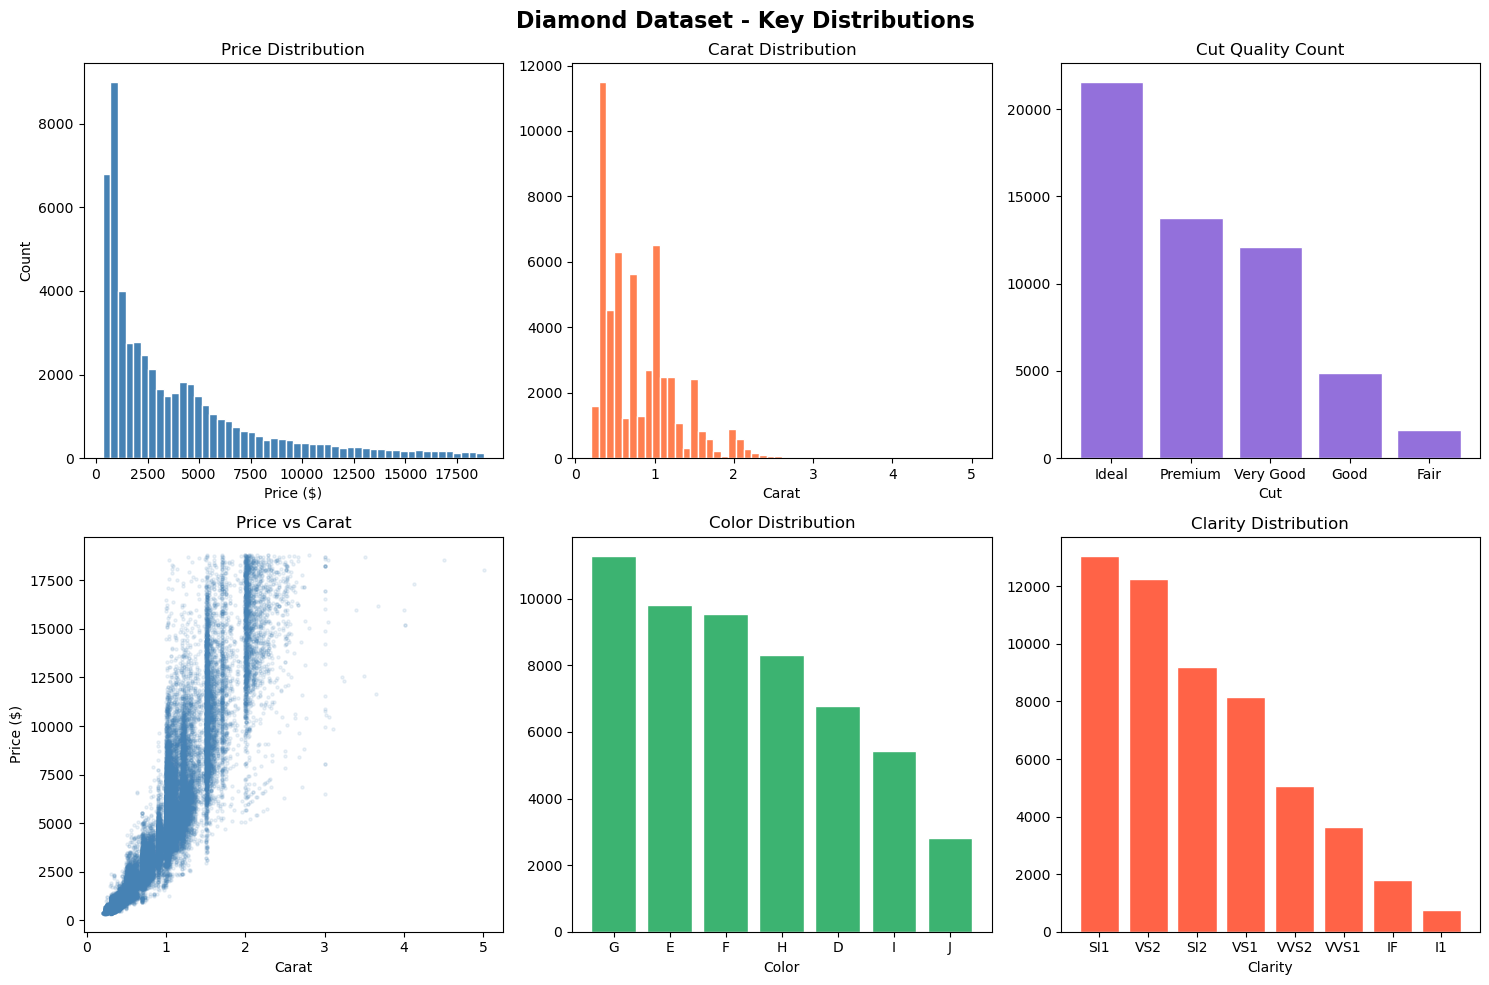

 Plots saved!


In [11]:
# ============================================================
# DATA VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Diamond Dataset - Key Distributions', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Count')

# 2. Carat distribution
axes[0,1].hist(df['carat'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Carat Distribution')
axes[0,1].set_xlabel('Carat')

# 3. Cut counts
cut_counts = df['cut'].value_counts()
axes[0,2].bar(cut_counts.index, cut_counts.values, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Cut Quality Count')
axes[0,2].set_xlabel('Cut')

# 4. Price vs Carat
axes[1,0].scatter(df['carat'], df['price'], alpha=0.1, color='steelblue', s=5)
axes[1,0].set_title('Price vs Carat')
axes[1,0].set_xlabel('Carat')
axes[1,0].set_ylabel('Price ($)')

# 5. Color counts
color_counts = df['color'].value_counts()
axes[1,1].bar(color_counts.index, color_counts.values, color='mediumseagreen', edgecolor='white')
axes[1,1].set_title('Color Distribution')
axes[1,1].set_xlabel('Color')

# 6. Clarity counts
clarity_counts = df['clarity'].value_counts()
axes[1,2].bar(clarity_counts.index, clarity_counts.values, color='tomato', edgecolor='white')
axes[1,2].set_title('Clarity Distribution')
axes[1,2].set_xlabel('Clarity')

plt.tight_layout()
plt.savefig('C:/Users/musta/dm-diamonds-analysis/data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plots saved!")

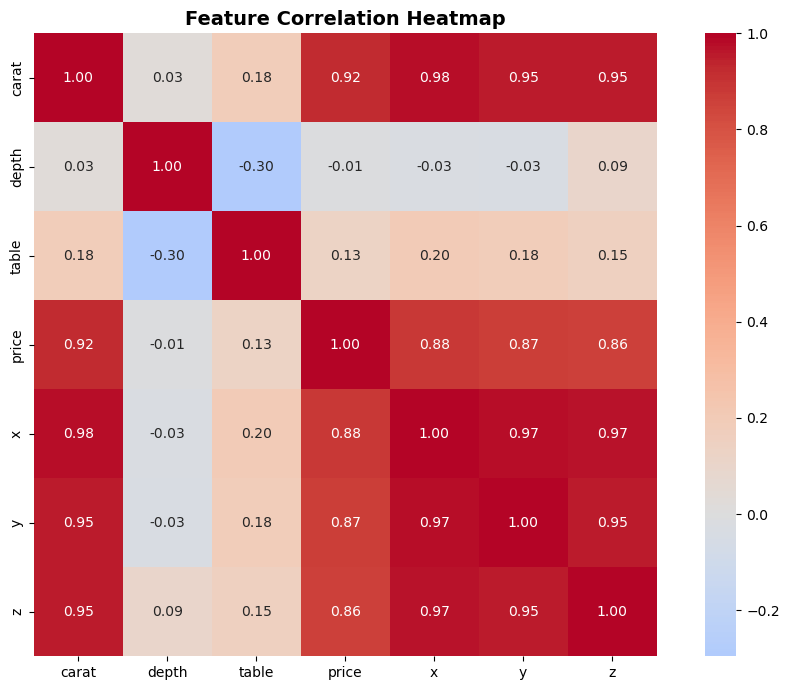

 Correlation heatmap saved!


In [12]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Unnamed: 0'])
correlation = numeric_cols.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/musta/dm-diamonds-analysis/data/correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved!")

---
## CRISP-DM Plan

| Phase | Activities | Techniques |
|-------|-----------|------------|
| Business Understanding | Define problem & goals | — |
| Data Understanding | EDA, distributions, correlations | Pandas, Seaborn |
| Data Preparation | Clean, encode, scale | LabelEncoder, StandardScaler |
| Modelling | Apply 4 mining techniques | KMeans, LinearRegression, PCA, RandomForest |
| Evaluation | Metrics per technique | R², Silhouette, Accuracy |
| Deployment | Interactive dashboard | Streamlit |